<a href="https://colab.research.google.com/github/dudaoliani/Tarefa-2-SSD---Maria-Eduarda-Oliani/blob/main/MVP_SSD_Tarefa2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP de SSD: Dimensionamento de uma Nova Unidade de Armazenamento em Nuvem

**Disciplina:** Sistemas de Suporte à Decisão
**Universidade de Brasília (UnB)**
**Aluna:** Maria Eduarda Moreno Oliani
**Matrícula:** 231013458

## Problema

Uma empresa de armazenamento de dados em nuvem vai abrir uma nova unidade. Antes de investir, a
diretoria precisa decidir três coisas: **qual capacidade contratar** (risco de não sustentar o SLA),
**quanto isso vai custar** e **em quantas fases implantar** a unidade até ela poder receber clientes de
produção.

## Base de dados

Cloud Resource Management Dataset (Kaggle, `bhagvendersingh/cloud-resource-management-dataset`),
1.000 registros com o estado de uma unidade de nuvem antes e depois de um processo de otimização de
recursos. Diferente de bases de telemetria de data center, esta base não traz classe de risco nem
custo total prontos: as duas coisas são construídas aqui a partir de regra de negócio explícita, o que
muda todo o caminho de modelagem em relação a uma base que já chega rotulada.

## Método adotado

1. Verificar a base antes de modelar (ela é sintética e algumas colunas são redundantes entre si);
2. construir os alvos de risco e custo;
3. treinar um modelo de risco (classificação) e um de custo (regressão) usando só as variáveis que a
   empresa define no projeto;
4. simular o espaço de dimensionamentos e escolher a capacidade mínima que atende a uma meta de risco
   a um custo aceitável (regra de restrição, não score ponderado);
5. propagar incerteza sobre essa escolha por simulação de Monte Carlo;
6. transformar a capacidade recomendada em um cronograma de implantação por fases.

## 1. Ambiente e carga dos dados

In [1]:
# No Colab, se algum pacote faltar: !pip install -q scikit-learn seaborn

import io, os, zipfile, urllib.request, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    r2_score, mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Ambiente pronto.")

Ambiente pronto.


In [2]:
DATASET = "bhagvendersingh/cloud-resource-management-dataset"
ARQUIVO = "cloud_resource_management_dataset.csv"

def carregar_base():
    if os.path.exists(ARQUIVO):
        return pd.read_csv(ARQUIVO)
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        return kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, DATASET, ARQUIVO)
    except Exception:
        pass
    url = f"https://www.kaggle.com/api/v1/datasets/download/{DATASET}"
    with urllib.request.urlopen(url) as resposta:
        pacote = zipfile.ZipFile(io.BytesIO(resposta.read()))
    nome_csv = [n for n in pacote.namelist() if n.endswith(".csv")][0]
    with pacote.open(nome_csv) as arquivo:
        return pd.read_csv(arquivo)

df_raw = carregar_base()
print(f"Registros: {df_raw.shape[0]}, variáveis: {df_raw.shape[1]}")
print(f"Nulos: {int(df_raw.isna().sum().sum())}, duplicados: {int(df_raw.duplicated().sum())}")
display(df_raw.head())

100%|██████████| 217k/217k [00:00<00:00, 10.0MB/s]

Registros: 1000, variáveis: 12
Nulos: 0, duplicados: 0


,initial_resource_pool,workload_complexity,initial_utilization,initial_cost_per_unit,initial_performance_score,optimized_resource_allocation,optimized_utilization,optimized_cost_per_unit,optimized_performance_score,utilization_improvement,cost_efficiency_improvement,performance_improvement
0,10.00000,4.370861,0.537027,0.778512,0.634541,16.958525,0.910718,0.236782,1.076087,69.585253,69.585253,69.585253
1,10.09009,9.556429,0.608380,0.774094,0.659336,15.272174,0.920833,0.376533,0.997959,51.358157,51.358157,51.358157
2,10.18018,7.587945,0.674589,0.971876,0.550094,16.012876,1.061092,0.415043,0.865268,57.294621,57.294621,57.294621
3,10.27027,6.387926,0.646445,0.774864,0.624975,16.602195,1.044997,0.297137,1.010290,61.652954,61.652954,61.652954
4,10.36036,2.404168,0.661312,0.781585,0.614349,18.769372,1.198068,0.147210,1.112987,81.165244,81.165244,81.165244


**Dicionário resumido.** `initial_*` são as decisões de projeto (capacidade, complexidade da carga,
ocupação planejada, custo unitário negociado, desempenho da configuração base). `optimized_*` e
`*_improvement` são o resultado após a otimização de recursos, só conhecido depois que a unidade já
está rodando. A base não tem coluna de tempo nem de risco pronta.

## 2. Verificação da base antes de modelar

Três checagens rápidas evitam erros que só apareceriam depois, quando já fosse tarde para corrigir o
modelo.

In [3]:
melhorias = ["utilization_improvement", "cost_efficiency_improvement", "performance_improvement"]
redundantes = np.allclose(df_raw[melhorias[0]], df_raw[melhorias[1]]) and \
              np.allclose(df_raw[melhorias[0]], df_raw[melhorias[2]])
print(f"1) As três colunas de ganho percentual são idênticas em toda a base: {redundantes}")
print("   Mantemos apenas uma, as outras duas seriam a mesma informação repetida.")

fator = df_raw["optimized_resource_allocation"] / df_raw["initial_resource_pool"]
ganho = df_raw["utilization_improvement"]
vazamento = np.allclose(df_raw["optimized_performance_score"],
                        df_raw["initial_performance_score"] * fator)
print(f"\n2) optimized_performance_score é função exata de initial_performance_score: {vazamento}")
print("   O mesmo vale para as demais colunas optimized_*. Por isso nenhuma delas pode ser usada")
print("   como variável preditora: entraria a resposta já pronta no modelo.")

acima_do_limite = (df_raw["optimized_utilization"] > 1).mean()
print(f"\n3) Registros com ocupação otimizada acima de 100% (fisicamente impossível): {acima_do_limite:.1%}")
print("   Por isso o eixo custo usa custo total, e não ocupação, como métrica de negócio.")

1) As três colunas de ganho percentual são idênticas em toda a base: True
   Mantemos apenas uma, as outras duas seriam a mesma informação repetida.

2) optimized_performance_score é função exata de initial_performance_score: True
   O mesmo vale para as demais colunas optimized_*. Por isso nenhuma delas pode ser usada
   como variável preditora: entraria a resposta já pronta no modelo.

3) Registros com ocupação otimizada acima de 100% (fisicamente impossível): 84.8%
   Por isso o eixo custo usa custo total, e não ocupação, como métrica de negócio.


## 3. Construção dos indicadores de risco e custo

**Custo.** O custo por unidade sozinho não diz nada sobre orçamento: uma unidade minúscula tem custo
unitário baixo e capacidade irrelevante. Usamos o custo total de operação:

$$\text{custo total} = \text{custo por unidade} \times \text{recursos alocados}$$

**Risco.** Como a empresa guarda dados de terceiros, o risco que importa é a unidade não sustentar o
desempenho contratado em SLA. Adotamos `optimized_performance_score = 1{,}00` como meta e `1{,}15`
como margem de segurança:

| Classe | Critério |
|---|---|
| Alto | score < 1,00 (não atinge o SLA) |
| Médio | 1,00 a 1,15 (atinge sem folga) |
| Baixo | acima de 1,15 (atinge com margem) |

In [4]:
SLA_META, SLA_MARGEM = 1.00, 1.15

df = df_raw.rename(columns={"utilization_improvement": "ganho_eficiencia_pct"}).copy()
df = df.drop(columns=["cost_efficiency_improvement", "performance_improvement"])

df["custo_total"] = df["optimized_cost_per_unit"] * df["optimized_resource_allocation"]

condicoes = [df["optimized_performance_score"] < SLA_META,
             df["optimized_performance_score"] < SLA_MARGEM]
df["risco_codigo"] = np.select(condicoes, [2, 1], default=0)
mapa_classes = {0: "Baixo", 1: "Médio", 2: "Alto"}
ordem_classes = ["Baixo", "Médio", "Alto"]
cores = {"Baixo": "#2a9d8f", "Médio": "#e9c46a", "Alto": "#e76f51"}
df["classe_risco"] = df["risco_codigo"].map(mapa_classes)

dist = df["classe_risco"].value_counts().reindex(ordem_classes)
print("Distribuição das classes de risco:")
display(pd.DataFrame({"registros": dist, "%": (dist / len(df) * 100).round(1)}))
print(f"Prever sempre a classe majoritária acertaria {dist.max() / len(df):.1%} das vezes (linha de base).")

Distribuição das classes de risco:


,registros,%
classe_risco,,
Baixo,445,44.5
Médio,389,38.9
Alto,166,16.6


Prever sempre a classe majoritária acertaria 44.5% das vezes (linha de base).


## 4. Como as decisões de projeto afetam risco e custo

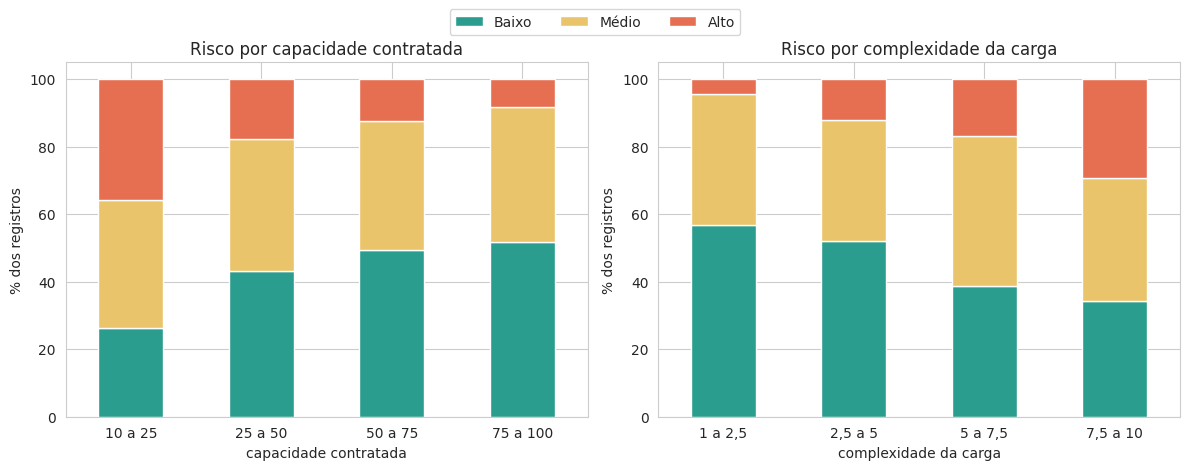

Capacidade maior reduz o risco (ganho de escala). Complexidade maior aumenta o risco.
Complexidade é definida pelo comercial, não é uma variável de engenharia a otimizar,
então o dimensionamento é a alavanca real deste MVP.


In [5]:
faixas_cap = pd.cut(df["initial_resource_pool"], bins=[0, 25, 50, 75, 100],
                    labels=["10 a 25", "25 a 50", "50 a 75", "75 a 100"])
faixas_cplx = pd.cut(df["workload_complexity"], bins=[0, 2.5, 5, 7.5, 10],
                     labels=["1 a 2,5", "2,5 a 5", "5 a 7,5", "7,5 a 10"])

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
for eixo, (faixa, titulo) in zip(eixos, [(faixas_cap, "capacidade contratada"),
                                         (faixas_cplx, "complexidade da carga")]):
    tabela = pd.crosstab(faixa, df["classe_risco"], normalize="index").reindex(columns=ordem_classes) * 100
    tabela.plot(kind="bar", stacked=True, ax=eixo, color=[cores[c] for c in ordem_classes], legend=False)
    eixo.set_title(f"Risco por {titulo}")
    eixo.set_xlabel(titulo); eixo.set_ylabel("% dos registros")
    eixo.tick_params(axis="x", rotation=0)
handles, labels = eixos[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(); plt.show()

print("Capacidade maior reduz o risco (ganho de escala). Complexidade maior aumenta o risco.")
print("Complexidade é definida pelo comercial, não é uma variável de engenharia a otimizar,")
print("então o dimensionamento é a alavanca real deste MVP.")

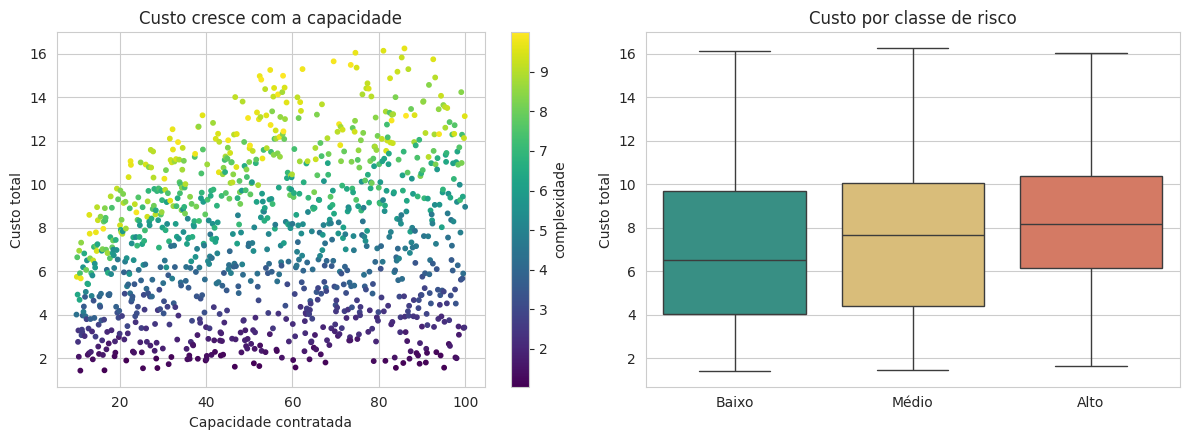

As unidades de risco Alto são, em média, mais baratas que as de risco Baixo.
É por isso que existe uma decisão a tomar: a opção segura não é a mais barata.


,custo médio
classe_risco,
Baixo,7.05
Médio,7.57
Alto,8.29


In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))

sc = eixos[0].scatter(df["initial_resource_pool"], df["custo_total"],
                      c=df["workload_complexity"], cmap="viridis", s=10)
eixos[0].set_xlabel("Capacidade contratada"); eixos[0].set_ylabel("Custo total")
eixos[0].set_title("Custo cresce com a capacidade")
plt.colorbar(sc, ax=eixos[0], label="complexidade")

sns.boxplot(data=df, x="classe_risco", y="custo_total", order=ordem_classes,
            palette=cores, ax=eixos[1])
eixos[1].set_title("Custo por classe de risco")
eixos[1].set_xlabel(""); eixos[1].set_ylabel("Custo total")
plt.tight_layout(); plt.show()

medias = df.groupby("classe_risco")["custo_total"].mean().reindex(ordem_classes)
print("As unidades de risco Alto são, em média, mais baratas que as de risco Baixo.")
print("É por isso que existe uma decisão a tomar: a opção segura não é a mais barata.")
display(medias.round(2).to_frame("custo médio"))

## 5. Modelos de risco e de custo

As preditoras são só as cinco variáveis que a empresa define antes de construir a unidade
(`initial_resource_pool`, `workload_complexity`, `initial_utilization`, `initial_cost_per_unit`,
`initial_performance_score`). Nenhuma coluna `optimized_*` entra, pela checagem 2 da seção 2.

Como as classes de risco são desbalanceadas (44,5% / 38,9% / 16,6%), o classificador usa
`class_weight="balanced"` e a métrica de comparação é o F1 macro, que dá peso igual às três classes.

F1 macro do modelo de linha de base (sempre a classe majoritária): 0.205
F1 macro do Random Forest: 0.951

Relatório de classificação:
              precision    recall  f1-score   support

       Baixo       0.99      0.98      0.98        89
       Médio       0.93      0.97      0.95        78
        Alto       0.97      0.88      0.92        33

    accuracy                           0.96       200
   macro avg       0.96      0.94      0.95       200
weighted avg       0.96      0.96      0.96       200



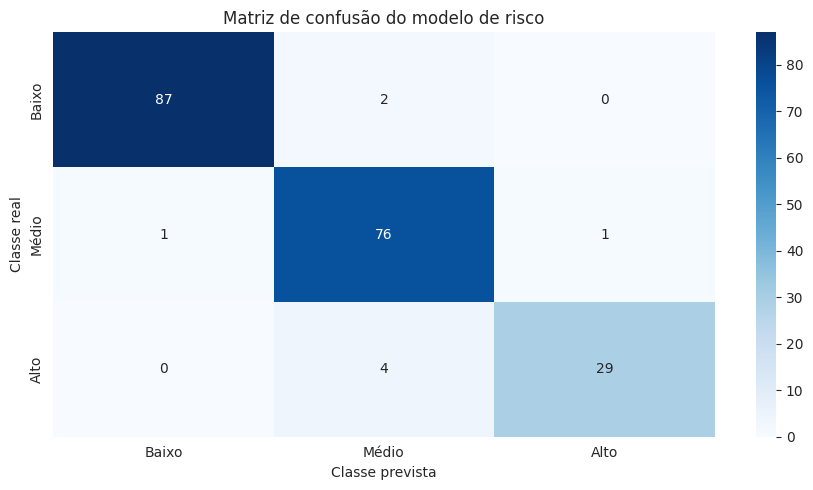

Unidades de risco Alto classificadas como Baixo (erro crítico): 0


In [7]:
DECISAO = ["initial_resource_pool", "workload_complexity", "initial_utilization",
           "initial_cost_per_unit", "initial_performance_score"]

X = df[DECISAO].copy()
y_risco = df["risco_codigo"].copy()
y_custo = df["custo_total"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_risco, test_size=0.20, random_state=RANDOM_STATE, stratify=y_risco
)

modelo_risco = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1))
])
modelo_risco.fit(X_train, y_train)
previsao = modelo_risco.predict(X_test)

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
f1_base = f1_score(y_test, baseline.predict(X_test), average="macro", zero_division=0)
f1_rf = f1_score(y_test, previsao, average="macro", zero_division=0)

print(f"F1 macro do modelo de linha de base (sempre a classe majoritária): {f1_base:.3f}")
print(f"F1 macro do Random Forest: {f1_rf:.3f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, previsao, target_names=ordem_classes, zero_division=0))

matriz = confusion_matrix(y_test, previsao, labels=[0, 1, 2])
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=ordem_classes, yticklabels=ordem_classes)
plt.xlabel("Classe prevista"); plt.ylabel("Classe real")
plt.title("Matriz de confusão do modelo de risco")
plt.tight_layout(); plt.show()

print(f"Unidades de risco Alto classificadas como Baixo (erro crítico): {int(matriz[2, 0])}")

> **Aviso metodológico.** Esta base é sintética: cada coluna `optimized_*` é uma função determinística
> das colunas `initial_*` (checagem 2 da seção 2). Isso significa que o desempenho alto do modelo
> reflete ter reencontrado uma fórmula, não ter aprendido um padrão de operação real com ruído. O papel
> deste modelo no MVP é servir de motor de simulação para comparar dimensionamentos entre si, não de
> previsão calibrada para uma base de produção real.

In [8]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_custo, test_size=0.20, random_state=RANDOM_STATE
)

modelo_custo = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
])
modelo_custo.fit(Xc_train, yc_train)
previsao_custo = modelo_custo.predict(Xc_test)

mae_baseline = mean_absolute_error(yc_test, np.full(len(yc_test), yc_train.mean()))
print(f"R² do modelo de custo: {r2_score(yc_test, previsao_custo):.3f}")
print(f"Erro médio absoluto: {mean_absolute_error(yc_test, previsao_custo):.3f} "
      f"(a linha de base, prever sempre a média, erraria {mae_baseline:.3f})")

R² do modelo de custo: 0.993
Erro médio absoluto: 0.219 (a linha de base, prever sempre a média, erraria 2.905)


## 6. Qual capacidade contratar

Em vez de um score ponderado entre risco e custo, este MVP adota uma **regra de restrição**, mais
próxima de como uma diretoria decide na prática: definir uma meta máxima de risco tolerável e, dentro
das capacidades que cumprem essa meta, escolher a mais barata.

Meta adotada: probabilidade de risco Alto abaixo de 20%. Avaliamos três perfis de portfólio comercial
(complexidade da carga 3, 5,5 e 8) porque o tipo de cliente que a unidade vai atender muda totalmente o
dimensionamento necessário.

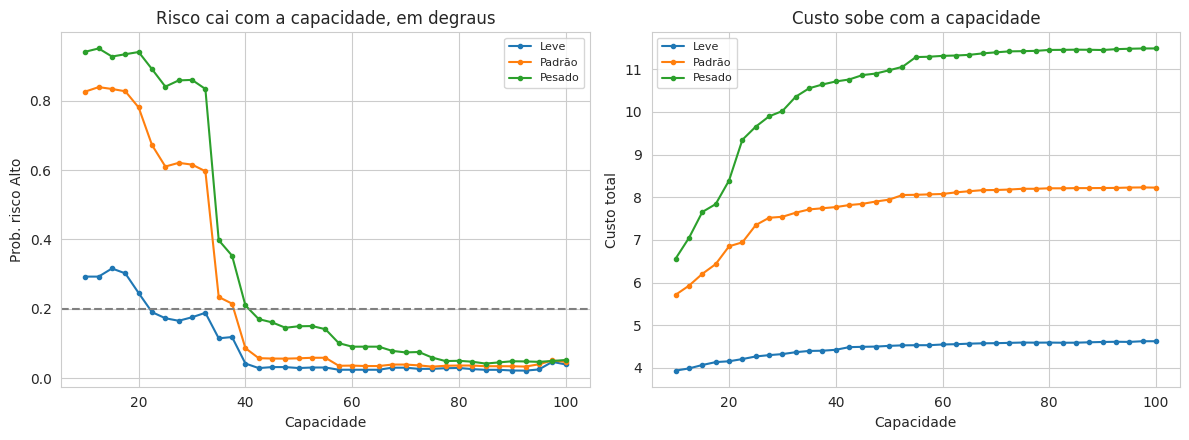

Capacidade recomendada por cenário (menor capacidade dentro da meta de risco):

  Leve    : capacidade 22.5, risco Alto 19.1%, custo 4.21
  Padrão  : capacidade 40.0, risco Alto 8.7%, custo 7.77
  Pesado  : capacidade 42.5, risco Alto 17.0%, custo 10.76

Decisão adotada para o restante do MVP: cenário Padrão, capacidade 40.0.


In [9]:
LIMIAR_RISCO = 0.20
CENARIOS = {"Leve": 3.0, "Padrão": 5.5, "Pesado": 8.0}

quartis = df[DECISAO].quantile([0.25, 0.50])
UTILIZACAO_BASE = quartis.loc[0.50, "initial_utilization"]
CUSTO_UNIT_BASE = quartis.loc[0.50, "initial_cost_per_unit"]
DESEMPENHO_BASE = quartis.loc[0.25, "initial_performance_score"]  # premissa conservadora

capacidades = np.arange(10, 100.5, 2.5)
candidatas = pd.DataFrame(
    [(cap, cplx, nome) for nome, cplx in CENARIOS.items() for cap in capacidades],
    columns=["initial_resource_pool", "workload_complexity", "cenario"]
)
candidatas["initial_utilization"] = UTILIZACAO_BASE
candidatas["initial_cost_per_unit"] = CUSTO_UNIT_BASE
candidatas["initial_performance_score"] = DESEMPENHO_BASE
candidatas["prob_risco_alto"] = modelo_risco.predict_proba(candidatas[DECISAO])[:, 2]
candidatas["custo_total"] = modelo_custo.predict(candidatas[DECISAO])

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
for nome in CENARIOS:
    r = candidatas[candidatas["cenario"] == nome]
    eixos[0].plot(r["initial_resource_pool"], r["prob_risco_alto"], marker="o", markersize=3, label=nome)
    eixos[1].plot(r["initial_resource_pool"], r["custo_total"], marker="o", markersize=3, label=nome)
eixos[0].axhline(LIMIAR_RISCO, linestyle="--", color="gray")
eixos[0].set_xlabel("Capacidade"); eixos[0].set_ylabel("Prob. risco Alto")
eixos[0].set_title("Risco cai com a capacidade, em degraus"); eixos[0].legend(fontsize=8)
eixos[1].set_xlabel("Capacidade"); eixos[1].set_ylabel("Custo total")
eixos[1].set_title("Custo sobe com a capacidade"); eixos[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Capacidade recomendada por cenário (menor capacidade dentro da meta de risco):\n")
recomendacoes = {}
for nome in CENARIOS:
    viaveis = candidatas[(candidatas["cenario"] == nome) & (candidatas["prob_risco_alto"] < LIMIAR_RISCO)]
    if len(viaveis) == 0:
        print(f"  {nome}: nenhuma capacidade testada atinge a meta de risco")
        continue
    escolhida = viaveis.sort_values("initial_resource_pool").iloc[0]
    recomendacoes[nome] = escolhida
    print(f"  {nome:8s}: capacidade {escolhida['initial_resource_pool']:.1f}, "
          f"risco Alto {escolhida['prob_risco_alto']:.1%}, custo {escolhida['custo_total']:.2f}")

CENARIO_BASE = "Padrão"
CAPACIDADE_RECOMENDADA = float(recomendacoes[CENARIO_BASE]["initial_resource_pool"])
print(f"\nDecisão adotada para o restante do MVP: cenário {CENARIO_BASE}, "
      f"capacidade {CAPACIDADE_RECOMENDADA:.1f}.")

O gráfico de risco não é uma curva suave: existe um patamar de capacidade abaixo do qual a unidade
fica presa em risco Alto, quase sem sensibilidade a pequenos aumentos, e acima do qual o risco despenca.
Essa é a informação de maior valor deste MVP: o dimensionamento da nova unidade é uma decisão de
degrau, não de ajuste fino. Reforçar a capacidade um pouco acima do mínimo tem pouco efeito; o que
importa é atravessar o patamar.

## 7. Incerteza sobre a capacidade escolhida

Os modelos das seções anteriores são determinísticos porque a base é determinística (seção 2). Na
prática, as premissas de projeto erram: o portfólio de clientes pode chegar mais complexo do que o
previsto, o fornecedor pode reajustar o preço, a ocupação inicial pode variar. Simulamos 5.000 cenários
sorteando essas premissas em torno do plano, mantendo a capacidade fixa na recomendada.

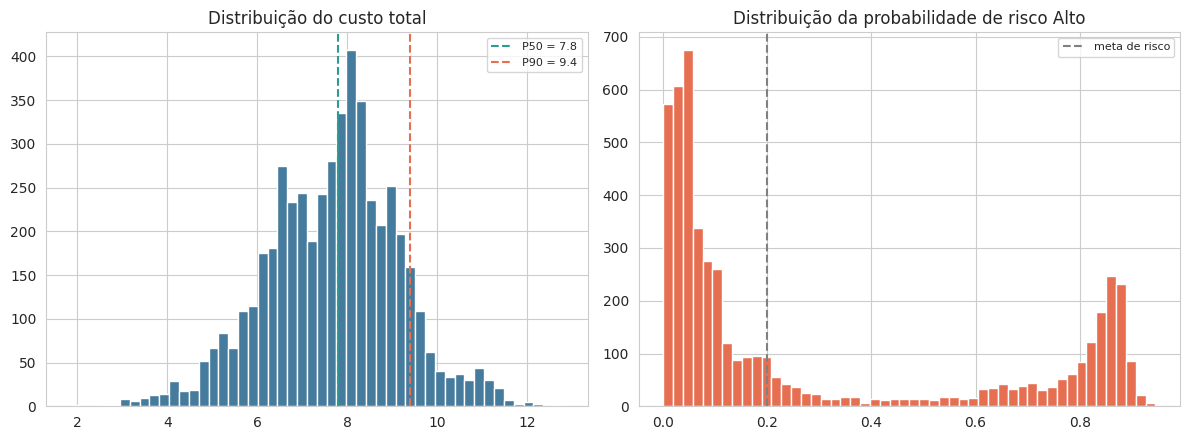

Custo mediano (P50): 7.80, custo no percentil 90 (P90): 9.40
Reserva de contingência recomendada (P90 menos P50): 1.60, 20.5% do orçamento base
Fração dos cenários simulados que cairia em risco Alto: 29.2%


In [10]:
N = 5000
g = np.random.default_rng(RANDOM_STATE)

def truncar(v, coluna):
    return np.clip(v, df[coluna].min(), df[coluna].max())

cenarios_mc = pd.DataFrame({
    "initial_resource_pool": np.full(N, CAPACIDADE_RECOMENDADA),
    "workload_complexity": np.clip(g.normal(CENARIOS[CENARIO_BASE], 1.2, N), 1.0, 10.0),
    "initial_utilization": truncar(g.normal(UTILIZACAO_BASE, 0.04, N), "initial_utilization"),
    "initial_cost_per_unit": truncar(g.normal(CUSTO_UNIT_BASE, 0.06, N), "initial_cost_per_unit"),
    "initial_performance_score": truncar(g.normal(DESEMPENHO_BASE, 0.04, N), "initial_performance_score"),
})
cenarios_mc["prob_risco_alto"] = modelo_risco.predict_proba(cenarios_mc[DECISAO])[:, 2]
cenarios_mc["custo_total"] = modelo_custo.predict(cenarios_mc[DECISAO])

p50, p90 = cenarios_mc["custo_total"].quantile([0.5, 0.9])
prob_falha = (cenarios_mc["prob_risco_alto"] >= 0.5).mean()

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
eixos[0].hist(cenarios_mc["custo_total"], bins=50, color="#457b9d")
eixos[0].axvline(p50, color="#2a9d8f", linestyle="--", label=f"P50 = {p50:.1f}")
eixos[0].axvline(p90, color="#e76f51", linestyle="--", label=f"P90 = {p90:.1f}")
eixos[0].set_title("Distribuição do custo total"); eixos[0].legend(fontsize=8)
eixos[1].hist(cenarios_mc["prob_risco_alto"], bins=50, color="#e76f51")
eixos[1].axvline(LIMIAR_RISCO, color="gray", linestyle="--", label="meta de risco")
eixos[1].set_title("Distribuição da probabilidade de risco Alto"); eixos[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Custo mediano (P50): {p50:.2f}, custo no percentil 90 (P90): {p90:.2f}")
print(f"Reserva de contingência recomendada (P90 menos P50): {p90 - p50:.2f}, "
      f"{(p90 / p50 - 1):.1%} do orçamento base")
print(f"Fração dos cenários simulados que cairia em risco Alto: {prob_falha:.1%}")

## 8. Cronograma de implantação

A capacidade recomendada não é instalada de uma vez, a obra é faseada em quatro trimestres. Como o
risco depende da capacidade instalada (seção 6), cada forma de faseamento gera uma curva de risco ao
longo do tempo. Comparamos instalar a capacidade em rampa linear (25%, 50%, 75%, 100%) contra entregar
logo no primeiro trimestre a capacidade mínima que atende à meta de risco.

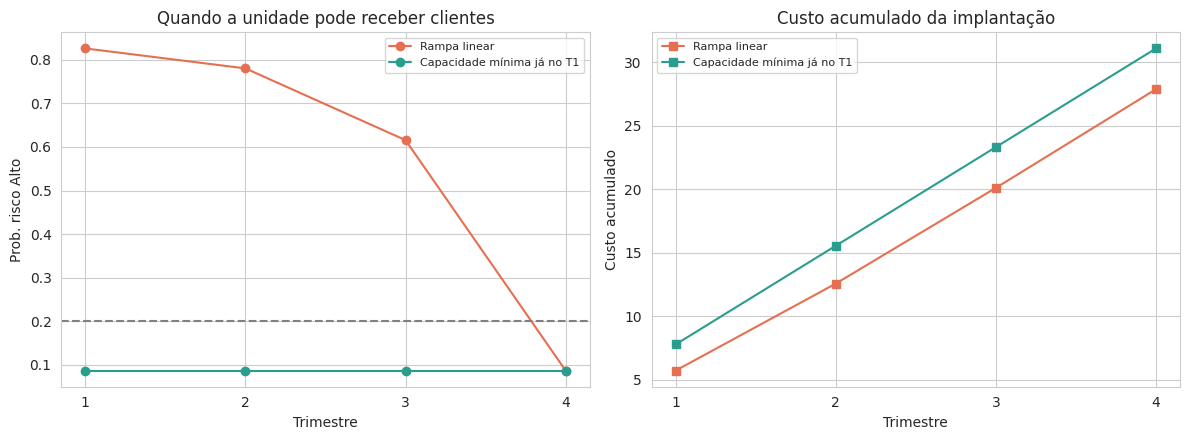

Rampa linear: go live em T4, custo do primeiro ano = 27.87
Capacidade mínima já no T1: go live em T1, custo do primeiro ano = 31.08


In [11]:
TRIMESTRES = [1, 2, 3, 4]
estrategias = {
    "Rampa linear": [0.25, 0.50, 0.75, 1.00],
    "Capacidade mínima já no T1": [1.00, 1.00, 1.00, 1.00],
}

linhas = []
for nome, fracoes in estrategias.items():
    for t, fracao in zip(TRIMESTRES, fracoes):
        capacidade_fase = CAPACIDADE_RECOMENDADA * fracao
        linha_fase = pd.DataFrame([{
            "initial_resource_pool": capacidade_fase,
            "workload_complexity": CENARIOS[CENARIO_BASE],
            "initial_utilization": UTILIZACAO_BASE,
            "initial_cost_per_unit": CUSTO_UNIT_BASE,
            "initial_performance_score": DESEMPENHO_BASE,
        }])
        prob_alto = modelo_risco.predict_proba(linha_fase[DECISAO])[0, 2]
        custo_t = modelo_custo.predict(linha_fase[DECISAO])[0]
        linhas.append({"estratégia": nome, "trimestre": t, "capacidade": round(capacidade_fase, 1),
                       "prob_risco_alto": round(prob_alto, 4), "custo_trimestre": round(custo_t, 2),
                       "status": "produção" if prob_alto < LIMIAR_RISCO else "homologação"})

cronograma = pd.DataFrame(linhas)
cronograma["custo_acumulado"] = cronograma.groupby("estratégia")["custo_trimestre"].cumsum()

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
for nome, cor in zip(estrategias, ["#e76f51", "#2a9d8f"]):
    r = cronograma[cronograma["estratégia"] == nome]
    eixos[0].plot(r["trimestre"], r["prob_risco_alto"], marker="o", color=cor, label=nome)
    eixos[1].plot(r["trimestre"], r["custo_acumulado"], marker="s", color=cor, label=nome)
eixos[0].axhline(LIMIAR_RISCO, linestyle="--", color="gray")
eixos[0].set_xticks(TRIMESTRES); eixos[0].set_xlabel("Trimestre"); eixos[0].set_ylabel("Prob. risco Alto")
eixos[0].set_title("Quando a unidade pode receber clientes"); eixos[0].legend(fontsize=8)
eixos[1].set_xticks(TRIMESTRES); eixos[1].set_xlabel("Trimestre"); eixos[1].set_ylabel("Custo acumulado")
eixos[1].set_title("Custo acumulado da implantação"); eixos[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for nome in estrategias:
    r = cronograma[cronograma["estratégia"] == nome]
    produtivos = r[r["prob_risco_alto"] < LIMIAR_RISCO]["trimestre"]
    golive = int(produtivos.min()) if len(produtivos) else None
    print(f"{nome}: go live em {'T' + str(golive) if golive else 'não atingido em 4 trimestres'}, "
          f"custo do primeiro ano = {r['custo_trimestre'].sum():.2f}")

A rampa linear mantém a unidade em risco Alto nos primeiros trimestres, porque uma unidade pequena
demais não gera escala suficiente para a otimização de recursos funcionar. Entregar a capacidade mínima
viável logo no primeiro trimestre custa mais no início, mas antecipa o go live comercial e encurta o
período em que a unidade custa sem faturar.

## 9. Conclusão

**Sobre os dados.** A base é sintética: três colunas de ganho percentual são a mesma informação
repetida, e todas as colunas `optimized_*` são funções exatas das colunas `initial_*`. Usar qualquer
uma delas como preditora vazaria a resposta para o modelo. Por isso os dois modelos usam só as cinco
variáveis que a empresa define antes de construir a unidade.

**Sobre o risco.** Existe um patamar de capacidade: abaixo dele, o risco de furar o SLA é alto e quase
insensível a pequenos aumentos de capacidade; acima dele, o risco despenca. O dimensionamento da nova
unidade é, na prática, uma decisão de degrau.

**Sobre o custo.** Risco e custo se opõem: as configurações mais baratas são também as mais arriscadas.
Por isso a decisão foi tratada como restrição (atender a uma meta de risco ao menor custo possível), e
não como uma média ponderada entre os dois critérios.

**Sobre o tempo.** A base não tem variável temporal, o cronograma foi construído a partir de como a
capacidade instalada evolui por fase. Faseamento não é neutro: dividir o investimento em parcelas
iguais atrasa o momento em que a unidade sustenta o SLA e, com isso, atrasa a receita.

**Limitações.** A base é sintética, os valores absolutos (capacidade, custo) não devem ser
transportados para um caso real sem recalibração. Não há variáveis de localização, energia ou
regulação, o MVP responde quanto e quando dimensionar, não onde instalar a unidade. O Monte Carlo
propaga incerteza das premissas de entrada, mas os modelos continuam determinísticos por dentro, não
capturam ruído operacional real.